# De la EDO al código orientado a objetos
**Módulo 4 — Implementación guiada y POO**

**Programación Científica 2026-1 · Universidad Nacional de Colombia**  
mbastidaso@unal.edu.co


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)


In [12]:
# ── Instalación de LaTeX para renderizado tipográfico (descomentar en Colab) ──
#!sudo apt-get update -qq
#!sudo apt-get install -qq texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import numpy as np
import matplotlib.pyplot as plt

# ── Configuración global de estilo matplotlib (igual que en clases anteriores) ──
plt.rcParams.update({
    "text.usetex"        : True,
    "font.family"        : "serif",
    "font.serif"         : ["Computer Modern Roman"],
    "font.size"          : 14,

    "axes.labelsize"     : 16,
    "axes.titlesize"     : 18,
    "xtick.labelsize"    : 12,
    "ytick.labelsize"    : 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction"    : "in",
    "ytick.direction"    : "in",

    "grid.color"         : "gray",
    "grid.linewidth"     : 0.3,
    "grid.alpha"         : 0.3,
    "grid.linestyle"     : "--",

    "figure.dpi"         : 120,
    "axes.spines.top"    : False,
    "axes.spines.right"  : False,
    "savefig.bbox"       : "tight",
    "savefig.dpi"        : 300,
})
print("Configuración OK")


Configuración OK


---
## De funciones a clases

**Ejemplo mínimo: una clase**

Antes de construir `Solver`, veamos los ingredientes de una clase con
un ejemplo trivial: una `Particula` con posición `x` y velocidad `v`,
que sabe `mover()`-se.

- `class`: define un nuevo tipo.
- `__init__`: se ejecuta al crear el objeto (el *constructor*).
- `self`: el objeto mismo; así accede a sus propios datos.
- **atributo**: un dato que vive dentro del objeto (`self.x`).
- **método**: una función que vive dentro del objeto (`mover`).

In [13]:
class Particula:
    """
    Ejemplo mínimo de clase: no resuelve ninguna EDO, solo ilustra
    que un objeto guarda datos (atributos) y sabe hacer algo (métodos).
    """
    def __init__(self, x, v):
        self.x = x   # atributo: posición
        self.v = v   # atributo: velocidad

    def mover(self, dt):
        # método: modifica el propio estado del objeto
        self.x += self.v * dt


p = Particula(x=0.0, v=2.0)
print("Posición inicial:", p.x)

p.mover(dt=0.5)
print("Posición tras mover(dt=0.5):", p.x)

p.mover(dt=0.5)
print("Posición tras un segundo mover(dt=0.5):", p.x)

Posición inicial: 0.0
Posición tras mover(dt=0.5): 1.0
Posición tras un segundo mover(dt=0.5): 2.0


**Observación:** cada llamada a `p.mover(dt)` no necesita que le
volvamos a pasar la posición ni la velocidad — el objeto `p` ya las
recuerda como atributos propios. 

In [14]:
class Vehiculo:
    def __init__(self, marca, modelo):
        self.marca = marca     # atributo
        self.modelo = modelo   # atributo
    
    def arrancar(self):
        return f"El {self.marca} {self.modelo} está en marcha."

class Auto(Vehiculo):
    def __init__(self, marca, modelo, puertas):
        super().__init__(marca, modelo) # Hereda de Vehiculo
        self.puertas = puertas  # atributo
        
    def abrir_puertas(self):
        return f"Abriendo las {self.puertas} puertas del {self.marca}."

# Creación de un objeto
mi_coche = Auto("BYD", "YuanUP", 4)
print(mi_coche.arrancar())       # Heredado: El BYD YuanUP está en marcha.
print(mi_coche.abrir_puertas())  # Propio: Abriendo las 4 puertas del BYD.


El BYD YuanUP está en marcha.
Abriendo las 4 puertas del BYD.


In [15]:
import math  # se necesita math.pi para calcular el área del círculo

class Figura:
    # Docstring: explica que esta es la clase base del patrón de herencia
    """
    Clase base: no implementa area(), obliga a cada subclase a
    definir su propia fórmula. Mismo patrón que Solver/Euler/RK4.
    """
    def area(self):
        # Este método se deja sin implementar a propósito
        # raise NotImplementedError obliga a que toda subclase lo sobrescriba
        raise NotImplementedError("Las subclases deben implementar area()")


class Circulo(Figura):
    # (Figura) indica que Circulo HEREDA de Figura
    def __init__(self, radio):
        # Circulo no necesita reescribir __init__ de Figura porque Figura
        # no tenía uno propio; aquí se define el único __init__ que existe
        self.radio = radio  # atributo propio de Circulo

    def area(self):
        # Este método SOBRESCRIBE el area() vacío de Figura
        # math.pi es la constante pi de la biblioteca estándar
        return math.pi * self.radio ** 2


class Rectangulo(Figura):
    # Rectangulo también hereda de Figura
    def __init__(self, base, altura):
        self.base = base      # atributo propio de Rectangulo
        self.altura = altura  # atributo propio de Rectangulo

    def area(self):
        # Otra implementación distinta de area(), con su propia fórmula
        return self.base * self.altura


# ── Uso de la clase: aquí se ve el valor de la herencia ─────────────────────
# Una lista puede contener objetos de distintas subclases de Figura
figuras = [Circulo(radio=2.0), Rectangulo(base=3.0, altura=4.0)]

# El mismo bucle llama a .area() sin saber de qué subclase es cada objeto
for f in figuras:
    # type(f).__name__ obtiene el nombre de la clase real del objeto f
    print(f"{type(f).__name__}: área = {f.area():.4f}")

Circulo: área = 12.5664
Rectangulo: área = 12.0000


In [16]:
class CuentaBancaria:
    # Docstring: explica el propósito de la clase
    """
    Ejemplo de clase con validación dentro de un método: nadie puede
    modificar el saldo sin pasar por depositar()/retirar().
    """
    def __init__(self, titular, saldo_inicial=0.0):
        # __init__ se ejecuta automáticamente al crear el objeto (constructor)
        # self.titular guarda el nombre como atributo del objeto
        self.titular = titular
        # self.saldo guarda el saldo inicial como atributo del objeto
        self.saldo = saldo_inicial

    def depositar(self, monto):
        # self permite acceder a los datos de ESTE objeto en particular
        # Validación: no se permite depositar un monto no positivo
        if monto <= 0:
            # raise lanza un error y detiene la ejecución del método
            raise ValueError("El monto a depositar debe ser positivo")
        # Si pasó la validación, se actualiza el atributo saldo
        self.saldo += monto  # equivalente a self.saldo = self.saldo + monto

    def retirar(self, monto):
        # Misma validación de monto positivo que en depositar
        if monto <= 0:
            raise ValueError("El monto a retirar debe ser positivo")
        # Validación adicional: no se puede retirar más de lo que hay
        if monto > self.saldo:
            raise ValueError("Saldo insuficiente")
        # Si ambas validaciones pasan, se descuenta el monto del saldo
        self.saldo -= monto  # equivalente a self.saldo = self.saldo - monto


# ── Uso de la clase ──────────────────────────────────────────────────────────
# Se crea un objeto (instancia) de CuentaBancaria; esto llama a __init__
cuenta = CuentaBancaria(titular="Ana", saldo_inicial=100.0)

# Se llama al método depositar() sobre el objeto cuenta
cuenta.depositar(50.0)
# Se accede al atributo saldo del objeto para verificar el resultado
print("Saldo tras depositar 50:", cuenta.saldo)

# Se llama al método retirar() sobre el mismo objeto
cuenta.retirar(30.0)
print("Saldo tras retirar 30:", cuenta.saldo)

# try/except captura el error esperado sin detener el programa
try:
    # Este retiro debe fallar porque supera el saldo disponible
    cuenta.retirar(1000.0)
except ValueError as e:
    # Se imprime el mensaje del error capturado
    print("Error esperado:", e)

Saldo tras depositar 50: 150.0
Saldo tras retirar 30: 120.0
Error esperado: Saldo insuficiente


---

# Diseño de la clase `Solver`

`Solver` guarda todo lo que `euler` y `rk4` reciben como parámetro:

- `self.f`: el campo vectorial (aquí, `dk_rhs`).
- `self.x`: el estado actual (empieza en `x0`).
- `self.t`, `self.dt`: tiempo actual y tamaño del paso.
- `self.kwargs`: parámetros extra que necesita `f` (aquí, `beta`, `alpha`).

El método `step()` **no se implementa** en `Solver`: lanza un error
para obligar a que cada subclase (`Euler`, `RK4`, ...) lo sobrescriba
con su propia fórmula.

In [17]:
class Solver:
    """
    Clase base para integradores numéricos de un PVI:
        dx/dt = f(x, t, **kwargs),  x(0) = x0

    No implementa step(): cada subclase decide cómo avanza un paso.
    """
    def __init__(self, f, x0, dt, **kwargs):
        self.f      = f
        self.dt     = dt
        self.kwargs = kwargs
        self.x      = np.array(x0, dtype=float)
        self.t      = 0.0
        self.historia = [self.x.copy()]
        self.tiempos  = [self.t]

    def step(self):
        """Avanza un paso de tiempo. Debe ser sobrescrito por la subclase."""
        raise NotImplementedError(
            "Las subclases deben implementar step()")

    def integrar(self, t_final):
        """Llama a step() repetidamente hasta llegar a t_final."""
        while self.t < t_final - 1e-9:
            self.step()
            self.historia.append(self.x.copy())
            self.tiempos.append(self.t)
        return np.array(self.tiempos), np.array(self.historia)

print("Clase Solver definida (step() todavía no implementado)")


Clase Solver definida (step() todavía no implementado)


### Subclase `Euler(Solver)`

`Euler` **hereda** `__init__` de `Solver` sin reescribirlo, y solo
**sobrescribe** `step()` con la fórmula de Euler.

In [18]:
class Euler(Solver):
    """Integrador de Euler explícito, como subclase de Solver."""
    def step(self):
        self.x = self.x + self.dt * self.f(self.x, self.t, **self.kwargs)
        self.t += self.dt

print("Clase Euler(Solver) definida")

Clase Euler(Solver) definida


### Demostración: mismos resultados, otra organización

Se instancia `Euler(dk_rhs, x0, dt, beta=..., alpha=...)`, se integra
hasta el mismo tiempo final, y se compara con la función `euler()` de
la parte 1 sobre la misma malla de tiempo.

Integración completa. Dimensiones de la solución: (151, 3)


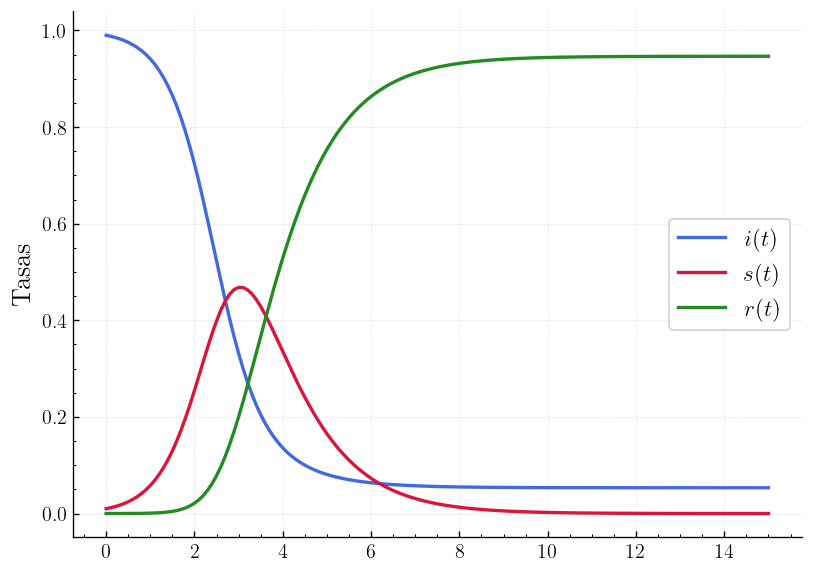

In [22]:
# ── RHS del modelo DK ──────────────────────────────────────────────────────
def dk_rhs(x, t, beta=2.0, alpha=1.0):
       """
       Lado derecho del modelo del chisme, con la firma f(t, x, ...)
       que exige scipy.integrate (tiempo primero, estado después).
       """
       i, s, r = x
       di = -beta * i * s
       ds =  beta * i * s - alpha * s * (s + r)
       dr =  alpha * s * (s + r)
       return np.array([di, ds, dr])

beta, alpha = 2.0, 1.0
x0_chisme   = [0.99, 0.01, 0.0]
dt          = 0.1  
T           = 15

# ── Enfoque orientado a objetos (esta parte) ────────────────────────────────
solver = Euler(f=dk_rhs, x0=x0_chisme, dt=dt, beta=beta, alpha=alpha)
tiempos, solucion = solver.integrar(T)

print("Integración completa. Dimensiones de la solución:", solucion.shape)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(tiempos, solucion[:, 0], lw=2, color="royalblue")
ax.plot(tiempos, solucion[:, 1], lw=2, color="crimson")
ax.plot(tiempos, solucion[:, 2], lw=2, color="forestgreen")
ax.set_ylabel(r"Tasas")
ax.grid(True)
ax.legend([r"$i(t)$", r"$s(t)$", r"$r(t)$"], loc="best", framealpha=0.9)

plt.tight_layout()
plt.show()



---
## Ejercicio: complete `RK4(Solver)`

Complete el método `step()` de la clase `RK4` usando la fórmula de
Runge-Kutta de orden 4:

$$
\begin{aligned}
k_1 &= h\,f(t_i,\; w_i) \\
k_2 &= h\,f\!\left(t_i + \tfrac{h}{2},\; w_i + \tfrac{1}{2}k_1\right) \\
k_3 &= h\,f\!\left(t_i + \tfrac{h}{2},\; w_i + \tfrac{1}{2}k_2\right) \\
k_4 &= h\,f\!\left(t_i + h,\; w_i + k_3\right) \\
w_{i+1} &= w_i + \tfrac{1}{6}(k_1 + 2k_2 + 2k_3 + k_4)
\end{aligned}
$$

Reutilice `self.f`, `self.x`, `self.t`, `self.dt`, `self.kwargs` — no
necesita reescribir `__init__` ni `integrar()`, ya los hereda de
`Solver`.

In [ ]:
class RK4(Solver):
    """
    Complete step() con la fórmula de Runge-Kutta de orden 4.
    Reutilice self.f, self.x, self.t, self.dt, self.kwargs.
    """
    def step(self):
        # k1 = ...
        # k2 = ...
        # k3 = ...
        # k4 = ...
        # actualizar self.x y self.t
        raise NotImplementedError("Implemente RK4.step()")


### Verificación

Una vez completado `RK4.step()`, la siguiente celda debe imprimir
`True`: el estado final del objeto `RK4` debe coincidir con el que
produce la función `rk4()` de la parte 1, sobre la misma malla.

In [ ]:
X_funcional_rk4 = rk4(dk_rhs, x0_chisme, t_arr, beta=beta, alpha=alpha)

solver_rk4 = RK4(f=dk_rhs, x0=x0_chisme, dt=dt, beta=beta, alpha=alpha)
t_rk4, X_objeto_rk4 = solver_rk4.integrar(T)

print("Estado final (función rk4()):", X_funcional_rk4[-1])
print("Estado final (objeto RK4)   :", X_objeto_rk4[-1])
print("¿Coinciden?:", np.allclose(X_funcional_rk4[-1], X_objeto_rk4[-1]))
